# Notebook 02l - PPO-CF on `MiniGrid-KeyCorridorS3R2-v0`

Compare PPO and PPO-CF from `config/envs/keycorridors3r2_cf.yaml`, changing
only `ppo.pg_mode` between arms. The base PPO hyperparameters are adapted from
RL Baselines3 Zoo's KeyCorridorS3R1 settings; the CF arm adds branch rollouts
from exact MiniGrid simulator states.


---
## Knobs


In [ ]:
# ----------------------------------------------------------------------------
# EDIT ME
# ----------------------------------------------------------------------------
ENV_CONFIG    = "keycorridors3r2_cf"
SEEDS         = None          # None -> use the config's seeds
FORCE_RETRAIN = True

RUN_ORACLE_CHECKS = True
RUN_CONTROL       = False
RUN_CF            = True
RUN_SHUFFLED      = False

ORACLE_CHECK_RUN  = "keycorridors3r2"
ORACLE_CHECK_CKPT = 0.75

OVERRIDES = {
    # YAML now contains the working fixed-layout/floor/CF recipe.
    # Quick smoke:
    # "ppo.total_timesteps": 100_000,
    # "run.seeds": (0,),
}
# ----------------------------------------------------------------------------


## 0. Setup


In [2]:
%load_ext autoreload
%autoreload 2

import sys, pathlib, time

ROOT = pathlib.Path.cwd()
if not (ROOT / "config").is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from config import make_config, seed_dir, RUNS_DIR, FIGURES_DIR
from dataio import load_trajectories, load_checkpoint, list_checkpoints
from utils.logging import read_scalars
from utils.plotting import savefig
from scripts.train import run_seeds

base = make_config(ENV_CONFIG, **OVERRIDES)
if SEEDS is not None:
    base = make_config(ENV_CONFIG, **{**OVERRIDES, "run.seeds": tuple(SEEDS)})
SEEDS = tuple(base.run.seeds)
STEM = base.run.run_name

ARMS = {
    k: make_config(ENV_CONFIG, **{**OVERRIDES, "run.seeds": SEEDS,
                                  "ppo.pg_mode": m, "run.run_name": f"{STEM}_{k}"})
    for k, m in [("gae", "gae"), ("cf", "cf_all_action"), ("shuf", "cf_shuffled")]
}
FIG = FIGURES_DIR / f"nb02_keycorridors3r2_{STEM}"
FIG.mkdir(parents=True, exist_ok=True)
ACTION_NAMES = ["left", "right", "forward", "pickup", "drop", "toggle", "done"]

print(ARMS["cf"].summary())
print()
print(f"arms: {[c.run.run_name for c in ARMS.values()]}   seeds: {list(SEEDS)}")


config             keycorridors3r2_cf
env                MiniGrid-KeyCorridorS3R2-v0  (n_envs=8, obs_norm=image)
layouts            1 fixed (cycle)
total_timesteps    500,000  per seed
rollout batch      1024  (8 envs x 128 steps)
updates            488
minibatch size     64  x 10 epochs
gamma / lambda     0.99 / 0.95
lr                 0.00025  (anneal=False)
encoder            cnn  (shared=True)
entropy            fixed, coef 0.03
prob floor         0.15 -> 0.02  (0 = off)
adv norm           batch  (min_std 1e-06)
policy gradient    cf_all_action  alpha_gae=1.0 alpha_cf=0.5, Q_g horizon=64 x2 rollouts, subsample=10%, restore=fast


reward shaping     off
warm start         none
seeds              [0]
checkpoints at     ['10%', '30%', '50%', '75%', '100%']

arms: ['keycorridors3r2_gae', 'keycorridors3r2_cf', 'keycorridors3r2_shuf']   seeds: [0]


---
# 1. Test The Oracle

The config uses `cf_restore: fast` for speed, while `cf_validate: true` checks
recorded transitions before training trusts the restore path.


In [3]:
from envs.env_pool import set_sim_state
from oracle.online import OnlineOracle, check_replay, check_centering, landscape_summary

if RUN_ORACLE_CHECKS:
    cfg = ARMS["cf"]
    K = len(ACTION_NAMES)
    sd = seed_dir(ORACLE_CHECK_RUN, SEEDS[0]) if ORACLE_CHECK_RUN else None
    traj_path = sd / "trajectories.npz" if sd else None
    if sd and traj_path.exists():
        traj = load_trajectories(traj_path)
        ckpts = list_checkpoints(sd / "checkpoints")
        if not ckpts:
            raise FileNotFoundError(f"no checkpoints found under {sd / 'checkpoints'}")
        loaded = [(p, load_checkpoint(p)) for p in ckpts]
        p_ck, ck = min(loaded, key=lambda pc: abs(pc[1].fraction - ORACLE_CHECK_CKPT))
        value_fn, probs_fn = ck.values, ck.probs
        src = f"{ORACLE_CHECK_RUN} @ {ck.fraction:.0%} ({p_ck.name})"
        N = min(800, len(traj))
        sims  = traj.sim_state[:N]
        acts  = traj.action[:N]
        rews  = traj.reward[:N]
        nsims = traj.next_sim_state[:N]
    else:
        from agents.ppo import PPOTrainer
        print(f"no completed trajectory at {traj_path}; using one live rollout for smoke-only oracle checks")
        _t = PPOTrainer(cfg, seed=SEEDS[0], progress=False)
        _t.pool.reset(); _t.collect_rollout()
        T, NE = cfg.ppo.n_steps, cfg.env.n_envs
        f = lambda a: a[:T].reshape((T * NE,) + a.shape[2:])
        sims, acts, rews, nsims = f(_t.buffer.sim_state), f(_t.buffer.actions), f(_t.buffer.rewards), f(_t.buffer.next_sim_state)
        value_fn, probs_fn = _t._values_np, _t._probs_np
        src = "fresh rollout"

    oracle = OnlineOracle(cfg.env.env_id, K, cfg.ppo.gamma,
                          {"fully_observable": cfg.env.fully_observable},
                          cfg.env.max_episode_steps, restore=cfg.ppo.cf_restore)
    print(f"oracle check source: {src}; {len(sims)} states; K={K}")


oracle check source: keycorridors3r2 @ 75% (ckpt_075.pt); 800 states; K=7


/opt/homebrew/anaconda3/envs/workbench/lib/python3.10/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


## 1.1 Restore, Centering, And Landscape Shape


In [4]:
if RUN_ORACLE_CHECKS:
    rep = check_replay(oracle, sims[:400], acts[:400], rews[:400], nsims[:400])
    print(f"restore replay exact over {rep['n']} transitions")
    print(f"  max reward error {rep['max_reward_error']:.3e}")
    print(f"  max state error  {rep['max_state_error']:.3e}")

    obs0 = np.stack([set_sim_state(oracle.env, s, elapsed_steps=0) for s in sims[:300]])
    pi = probs_fn(obs0)
    a_cf, q_cf, diag = oracle.a_g(
        sims[:300], pi[:300], probs_fn, value_fn,
        horizon=cfg.ppo.cf_horizon, n_rollouts=cfg.ppo.cf_rollouts,
        bootstrap_tail=cfg.ppo.cf_bootstrap_tail, chunk=cfg.ppo.cf_branch_envs)
    c = check_centering(a_cf, pi[:300])
    s_ = landscape_summary(a_cf, q_cf, pi[:300], spread_threshold=cfg.oracle.spread_threshold)

    print()
    print("Q_g diagnostics")
    print(f"  branches that saw reward         {diag['reward_coverage']:.3f}")
    print(f"  branches terminating within H    {diag['terminated_within_horizon']:.3f}")
    print(f"  states with reward in some branch {diag['frac_states_any_reward']:.3f}")
    print()
    print("Landscape")
    print(f"  centering max |sum pi*A_CF|      {c['max_abs']:.3e}")
    print(f"  mean |A_CF|                      {s_['mean_abs_a_cf']:.4f}")
    print(f"  frac states with spread > {cfg.oracle.spread_threshold}    {s_['frac_states_with_spread']:.3f}")
    print(f"  all finite                       {s_['finite']}")
    print("  best action by A_CF:")
    for name, count in zip(ACTION_NAMES, s_["best_action_counts"]):
        print(f"    {name:8s} {count:5d}")


restore replay exact over 400 transitions
  max reward error 0.000e+00
  max state error  0.000e+00

Q_g diagnostics
  branches that saw reward         0.000
  branches terminating within H    0.000
  states with reward in some branch 0.000

Landscape
  centering max |sum pi*A_CF|      7.451e-09
  mean |A_CF|                      0.0030
  frac states with spread > 0.01    0.363
  all finite                       True
  best action by A_CF:
    left       120
    right       82
    forward     67
    pickup      19
    drop         0
    toggle      12
    done         0


## 1.2 Oracle Verdict


In [5]:
if RUN_ORACLE_CHECKS:
    assert rep["max_state_error"] == 0.0
    assert rep["max_reward_error"] == 0.0
    assert c["max_abs"] < 1e-4
    assert s_["finite"]
    print("oracle checks passed")


oracle checks passed


---
# 2. Train Arms


In [6]:
def train_arm(key):
    c = ARMS[key]
    done = all((seed_dir(c.run.run_name, s) / "scalars.csv").exists() for s in c.run.seeds)
    if done and not FORCE_RETRAIN:
        print(f"found existing run at {RUNS_DIR / c.run.run_name} -- skipping")
        return None
    t0 = time.time()
    out = run_seeds(c)
    print()
    print(f"{key}: {(time.time() - t0) / 60:.1f} min total")
    return out

if RUN_CONTROL:
    train_arm("gae")
if RUN_CF:
    train_arm("cf")
if RUN_SHUFFLED:
    train_arm("shuf")



=== seed 0 ====================================================
  oracle check: replay exact over 96 transitions (reward err 0, state err 0); centering max 3.40e-08
  upd    10/488  step   10,240  ret   0.000  succ 0.00  sg1 0.16 sg2 0.06  ent 1.910  advstd 9.15e-03  ev  0.834  100 sps
  upd    20/488  step   20,480  ret   0.012  succ 0.03  sg1 0.26 sg2 0.08  ent 1.841  advstd 1.18e-02  ev  0.662  102 sps
  upd    30/488  step   30,720  ret   0.010  succ 0.03  sg1 0.33 sg2 0.11  ent 1.771  advstd 1.12e-02  ev  0.296  102 sps
  upd    40/488  step   40,960  ret   0.016  succ 0.04  sg1 0.45 sg2 0.18  ent 1.759  advstd 1.95e-02  ev  0.766  102 sps
  upd    50/488  step   51,200  ret   0.010  succ 0.03  sg1 0.57 sg2 0.26  ent 1.748  advstd 1.25e-02  ev  0.145  102 sps
  upd    60/488  step   61,440  ret   0.013  succ 0.03  sg1 0.61 sg2 0.27  ent 1.835  advstd 9.77e-03  ev  0.592  102 sps
  upd    70/488  step   71,680  ret   0.013  succ 0.03  sg1 0.55 sg2 0.20  ent 1.790  advstd 5.77e-03 

---
# 3. Compare Arms


In [7]:
scal = {k: {s: read_scalars(seed_dir(c.run.run_name, s) / "scalars.csv")
            for s in c.run.seeds if (seed_dir(c.run.run_name, s) / "scalars.csv").exists()}
        for k, c in ARMS.items()}
scal = {k: v for k, v in scal.items() if v}

THRESH = 0.8
def frames_to(d, col="success_rate_100", thresh=THRESH):
    hit = d.loc[d[col] >= thresh, "global_step"]
    return int(hit.iloc[0]) if len(hit) else None

rows = []
for arm, per_seed in scal.items():
    for s, d in per_seed.items():
        rows.append({
            "arm": arm,
            "seed": s,
            f"frames_to_{THRESH:g}": frames_to(d),
            "final_return": round(float(d["mean_return_100"].iloc[-1]), 3),
            "final_success": round(float(d["success_rate_100"].iloc[-1]), 3),
            "best_success": round(float(d["success_rate_100"].max()), 3),
            "final_sg1": round(float(d["subgoal1_rate_100"].iloc[-1]), 3) if "subgoal1_rate_100" in d else None,
            "final_sg2": round(float(d["subgoal2_rate_100"].iloc[-1]), 3) if "subgoal2_rate_100" in d else None,
            "entropy_last": round(float(d["entropy"].iloc[-1]), 3),
            "ev_median": round(float(d["explained_variance"].median()), 3),
            "kl_median": round(float(d["approx_kl"].median()), 4),
            "clipfrac_median": round(float(d["clipfrac"].median()), 3),
            "cf_coverage": (round(float(d["cf_reward_coverage"].mean()), 3)
                            if "cf_reward_coverage" in d else None),
            "cf_corr_gae": (round(float(d["cf_corr_gae"].mean()), 3)
                            if "cf_corr_gae" in d else None),
        })
cmp_df = pd.DataFrame(rows).sort_values(["arm", "seed"])
display(cmp_df)

print(f"median frames to success >= {THRESH:g}")
for arm, g in cmp_df.groupby("arm") if not cmp_df.empty else []:
    v = g[f"frames_to_{THRESH:g}"].dropna()
    print(f"  {arm:4s} {('%.0f' % v.median()) if len(v) else 'never':>10s}   ({len(v)}/{len(g)} seeds reached it)")


,arm,seed,frames_to_0.8,final_return,final_success,best_success,final_sg1,final_sg2,entropy_last,ev_median,kl_median,clipfrac_median,cf_coverage,cf_corr_gae
1,cf,0,143360,0.939,1.0,1.0,1.0,1.0,0.166,0.834,0.0100,0.075,0.727,0.201
0,gae,0,194560,0.941,1.0,1.0,1.0,1.0,0.178,0.776,0.0127,0.122,NaN,NaN


median frames to success >= 0.8
  cf       143360   (1/1 seeds reached it)
  gae      194560   (1/1 seeds reached it)


## 3.1 Curves And CF Health


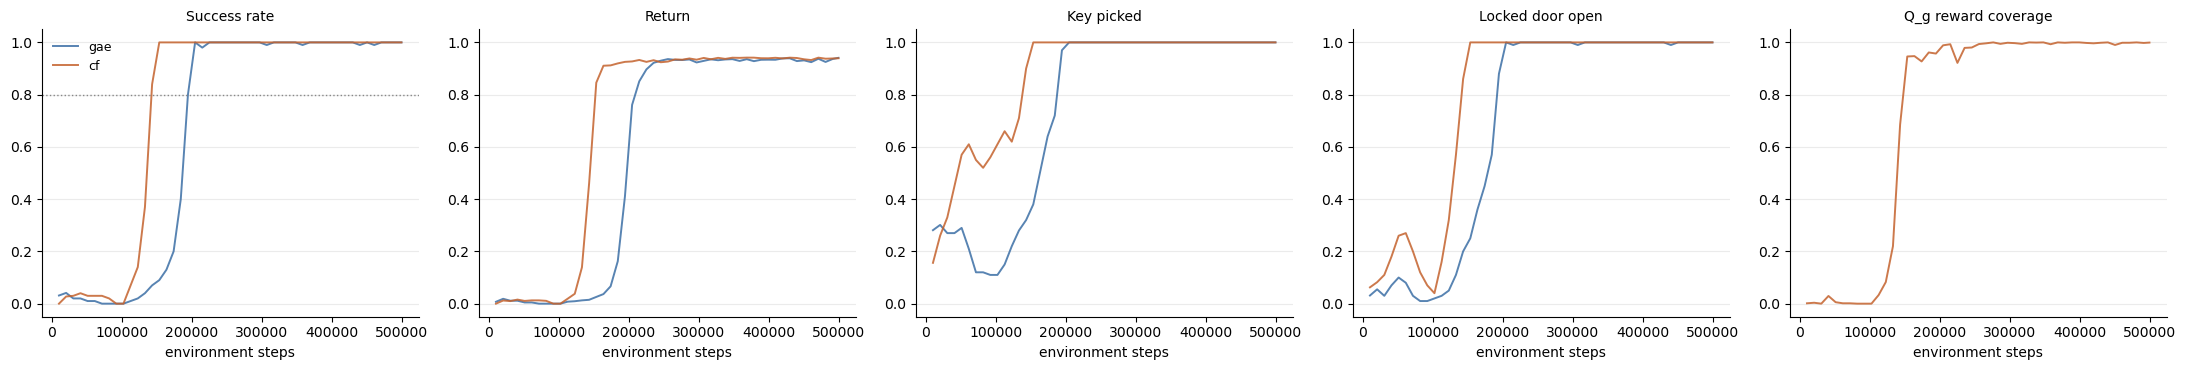


keycorridors3r2_cf  (seed 0)
  cf_centering         mean +7.033e-06  last +6.613e-06
  cf_reward_coverage   mean +0.7267  last +0.9993
  cf_corr_gae          mean +0.2009  last +0.563
  cf_mean_abs          mean +1.27  last +1.056
  cf_n_cf_states       mean +102  last +102


In [8]:
if scal:
    fig, axes = plt.subplots(1, 5, figsize=(22, 3.8))
    colors = {"gae": "#3b6ea5", "cf": "#c4622d", "shuf": "#7a7a7a"}
    panels = [("success_rate_100", "Success rate"),
              ("mean_return_100", "Return"),
              ("subgoal1_rate_100", "Key picked"),
              ("subgoal2_rate_100", "Locked door open"),
              ("cf_reward_coverage", "Q_g reward coverage")]
    for ax, (col, title) in zip(axes, panels):
        for arm, per_seed in scal.items():
            for i, (s, d) in enumerate(per_seed.items()):
                if col not in d.columns or not np.isfinite(d[col]).any():
                    continue
                ax.plot(d["global_step"], d[col], lw=1.4, alpha=0.85, color=colors[arm],
                        label=arm if i == 0 else None)
        ax.set_title(title, fontsize=10)
        ax.set_xlabel("environment steps")
        ax.spines[["top", "right"]].set_visible(False)
        ax.grid(axis="y", alpha=0.25)
    axes[0].axhline(THRESH, color="#888", ls=":", lw=1)
    for ax in axes[:4]:
        ax.set_ylim(-0.05, 1.05)
    axes[0].legend(frameon=False, fontsize=9)
    fig.tight_layout()
    savefig(fig, FIG / "arms.png")
    plt.show()

    for arm in ("cf", "shuf"):
        if arm not in scal:
            continue
        seed0 = sorted(scal[arm])[0]
        d = scal[arm][seed0]
        print()
        print(f"{ARMS[arm].run.run_name}  (seed {seed0})")
        for col in ["cf_centering", "cf_reward_coverage", "cf_corr_gae", "cf_mean_abs", "cf_n_cf_states"]:
            if col not in d.columns or not np.isfinite(d[col]).any():
                print(f"  {col:20s} not logged")
                continue
            print(f"  {col:20s} mean {d[col].mean():+.4g}  last {d[col].iloc[-1]:+.4g}")


## 3.2 Action Collapse Check


,run,seed,action,sample_frac,mean_pi,p05_pi
0,keycorridors3r2_gae,0,left,0.077180,0.076721,0.002858
1,keycorridors3r2_gae,0,right,0.305808,0.306773,0.003306
2,keycorridors3r2_gae,0,forward,0.200259,0.199488,0.002873
3,keycorridors3r2_gae,0,pickup,0.134662,0.135254,0.003001
4,keycorridors3r2_gae,0,drop,0.094406,0.094086,0.002858
5,keycorridors3r2_gae,0,toggle,0.136214,0.137291,0.002864
6,keycorridors3r2_gae,0,done,0.051470,0.050388,0.002857
7,keycorridors3r2_cf,0,left,0.192903,0.193001,0.002857
8,keycorridors3r2_cf,0,right,0.194840,0.195638,0.002857
9,keycorridors3r2_cf,0,forward,0.236584,0.236387,0.002860


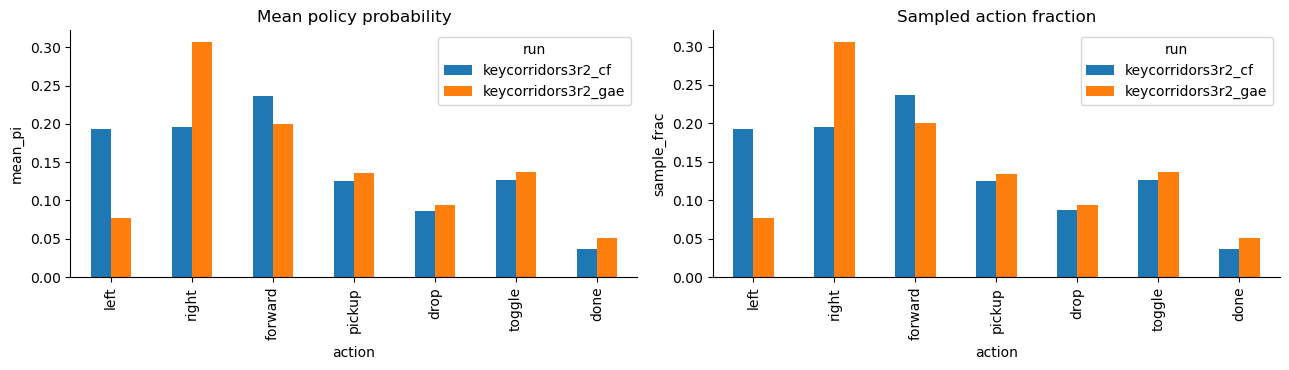

In [9]:
def load_action_summary(run_name, seeds):
    rows = []
    for s in seeds:
        path = seed_dir(run_name, s) / "trajectories.npz"
        if not path.exists():
            continue
        traj = load_trajectories(path)
        acts = traj.action.astype(int)
        probs = traj.probs.astype(float)
        for a, name in enumerate(ACTION_NAMES):
            rows.append({
                "run": run_name,
                "seed": s,
                "action": name,
                "sample_frac": float((acts == a).mean()),
                "mean_pi": float(probs[:, a].mean()),
                "p05_pi": float(np.quantile(probs[:, a], 0.05)),
            })
    return rows

action_rows = []
for arm, c in ARMS.items():
    if arm == "shuf" and not RUN_SHUFFLED:
        continue
    action_rows.extend(load_action_summary(c.run.run_name, c.run.seeds))
action_df = pd.DataFrame(action_rows)
display(action_df)

if not action_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
    for ax, val, title in [(axes[0], "mean_pi", "Mean policy probability"),
                           (axes[1], "sample_frac", "Sampled action fraction")]:
        piv = action_df.pivot_table(index="action", columns="run", values=val, aggfunc="mean").loc[ACTION_NAMES]
        piv.plot(kind="bar", ax=ax)
        ax.set_title(title)
        ax.set_ylabel(val)
        ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()
    savefig(fig, FIG / "action_compare.png")
    plt.show()


## 4. Reading The Result

A useful PPO-CF improvement should show higher success or faster time-to-success
without KL/clipfrac spikes, and without `pickup` or `toggle` collapsing to near
zero probability. If Q_g reward coverage is near zero at H=64, increase horizon
before interpreting the CF arm.
